## Lab 2 Estadística Descriptiva Básica 2 

## Series de tiempo

El siguiente [dataset](https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv) contiene información del precio del eur/usd  desde el 05/07/2022/ hasta el 12/05/2023 con periodicidad de una hora. El data frame contiene el precio de apertura, cierrre, valor más bajo cotizado, valor más alto cotizado, volumen, spread etc. Para este dataset, realizar lo siguiente:

In [134]:
# Importar librerías necesarias para todo el laboratorio

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fitter import Fitter
import seaborn as sns
import re
from scipy import stats



1. Leer el dataset desde el github.
2. Definir como indice la columna time.
3. Obtenga información del data frame.

4. Determine si hay null, nan en el data frame.

5. Emplea la notacion Pascal Case y trabaja solo con la columa del precio de cierre del eur/usd.  

6. Ahora vamos a determinar cual es la mejor distribución estadística que se ajusta a la diferencia del precio de cierre cada hora, para ello realizamos lo siguiente:
- Determine la diferencia de precio entre horas, agregue una nueva columna llamada DiffPrice, en este punto tu dataframe debe tener solo dos columnas Close, DiffPrice y el indice debe ser el tiempo.
- Para la nueva columna construya un histograma de los datos.
- Determine la mejor distribucion estadística que se ajusta al histograma anterior, para ello puede emplear lo siguente:


https://pypi.org/project/fitter/

Con el metodo get_distributions(), podemos ver todas las distribuciones estadisticas de la libreria. Ajusta a la mejor.  Puede consultar [esta](https://medium.com/the-researchers-guide/finding-the-best-distribution-that-fits-your-data-using-pythons-fitter-library-319a5a0972e9)  página si desea ver un ejemplo.


7. Para el data frame, seleccionemos solo los datos del 2023.

8. El comando groupby permite agrupar los datos con la periodicidad deseada: 1 dias, 2 dias, 1 mes etc. Determina el promedio con una periodicidad de 15 dias, con periodidicidad de 1 semana, y una periodicidad de 1 mes.

9. Para los datos asociados a los meses de 2023, construya un histograma para cada mes.  Para ello puedo emplear el metodo groupby. Notetese que si no  realiza una operación después de aplicar el metodo grouby, podrias iterar sobre dicho objeto, por ejemplo:

In [135]:
# 1. Leer el dataset desde GitHub
url = 'https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv'
df = pd.read_csv(url)

In [136]:
# 2. Definir como índice la columna 'time'
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

In [137]:
# 3. Obtener información del DataFrame
print("Información general del DataFrame:")
print(df.info())
print("\nPrimeras filas:")
print(df.head())

Información general del DataFrame:
<class 'pandas.DataFrame'>
DatetimeIndex: 5000 entries, 2022-07-25 13:00:00 to 2023-05-12 23:00:00
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          5000 non-null   int64  
 1   open                5000 non-null   float64
 2   high                5000 non-null   float64
 3   low                 5000 non-null   float64
 4   close               5000 non-null   float64
 5   tick_volume         5000 non-null   int64  
 6   spread              5000 non-null   int64  
 7   real_volume         5000 non-null   int64  
 8   MeanCloseOpen       5000 non-null   float64
 9   Diff_Close          5000 non-null   float64
 10  Diff_Open           5000 non-null   float64
 11  Diff_MeanCloseOpen  5000 non-null   float64
dtypes: float64(8), int64(4)
memory usage: 507.8 KB
None

Primeras filas:
                     Unnamed: 0     open     high      low    close  \
ti

In [138]:
# 4. Verificar valores nulos o NaN
print("\nValores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
Unnamed: 0            0
open                  0
high                  0
low                   0
close                 0
tick_volume           0
spread                0
real_volume           0
MeanCloseOpen         0
Diff_Close            0
Diff_Open             0
Diff_MeanCloseOpen    0
dtype: int64


In [139]:
# 5. Trabajar solo con la columna de cierre en PascalCase
df = df.rename(columns={'close': 'Close'})
df = df[['Close']]
print("\nDataFrame solo con la columna Close:")
print(df.head())


DataFrame solo con la columna Close:
                       Close
time                        
2022-07-25 13:00:00  1.02345
2022-07-25 14:00:00  1.02299
2022-07-25 15:00:00  1.02457
2022-07-25 16:00:00  1.02485
2022-07-25 17:00:00  1.02181


In [140]:
# 6. Calcular la diferencia de precio entre horas y agregar columna DiffPrice
df['DiffPrice'] = df['Close'].diff()
df = df.dropna()
print("\nDataFrame con columna DiffPrice:")
print(df.head())



DataFrame con columna DiffPrice:
                       Close  DiffPrice
time                                   
2022-07-25 14:00:00  1.02299   -0.00046
2022-07-25 15:00:00  1.02457    0.00158
2022-07-25 16:00:00  1.02485    0.00028
2022-07-25 17:00:00  1.02181   -0.00304
2022-07-25 18:00:00  1.02099   -0.00082


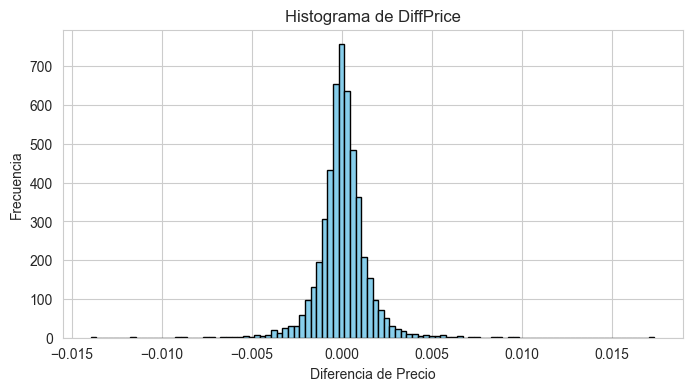

In [141]:
# Histograma de la columna DiffPrice
plt.figure(figsize=(8,4))
plt.hist(df['DiffPrice'], bins=100, color='skyblue', edgecolor='black')
plt.title('Histograma de DiffPrice')
plt.xlabel('Diferencia de Precio')
plt.ylabel('Frecuencia')
plt.show()

Mejor distribución: {'lognorm': {'s': np.float64(0.009509964461157715), 'loc': np.float64(-0.1471693008245066), 'scale': np.float64(0.14717494036949658)}}


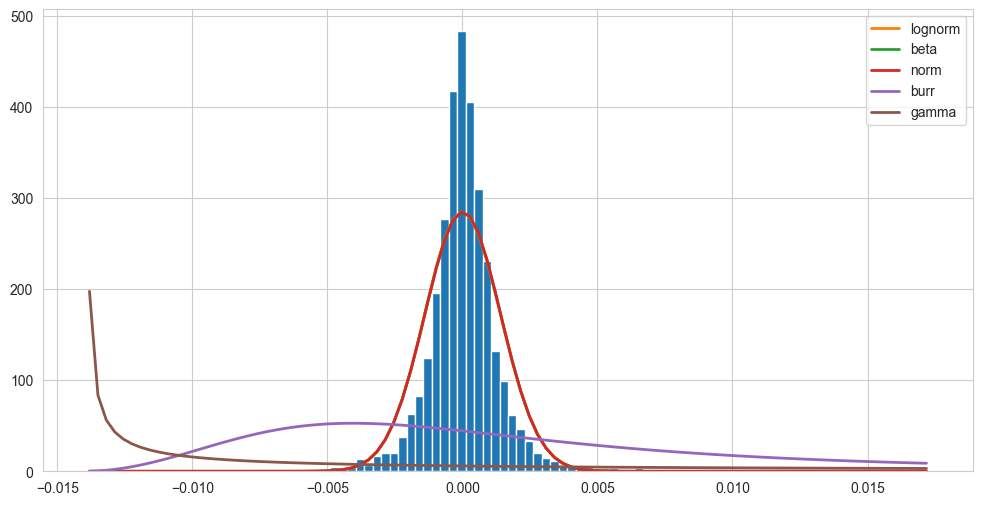

In [142]:
# Ajuste de la mejor distribución estadística (usando Fitter)
f = Fitter(df['DiffPrice'], distributions=['gamma', 'lognorm', 'beta', 'burr', 'norm'])
f.fit()
f.summary()
print('Mejor distribución:', f.get_best(method='sumsquare_error'))

In [143]:
# 7. Seleccionar solo datos del año 2023
df_2023 = df.loc['2023']
print("\nDatos del año 2023:")
print(df_2023.head())


Datos del año 2023:
                       Close  DiffPrice
time                                   
2023-01-02 00:00:00  1.06796   -0.00200
2023-01-02 01:00:00  1.06965    0.00169
2023-01-02 02:00:00  1.07058    0.00093
2023-01-02 03:00:00  1.06896   -0.00162
2023-01-02 04:00:00  1.06880   -0.00016


In [144]:
# 8. Agrupar y promediar por diferentes periodos
print("\nPromedio cada 15 días:")
print(df_2023.groupby(pd.Grouper(freq='15D')).mean().head())

print("\nPromedio semanal:")
print(df_2023.groupby(pd.Grouper(freq='W')).mean().head())

print("\nPromedio mensual:")
print(df_2023.groupby(pd.Grouper(freq='ME')).mean().head())


Promedio cada 15 días:
               Close  DiffPrice
time                           
2023-01-02  1.069361   0.000047
2023-01-17  1.085565   0.000015
2023-02-01  1.077679  -0.000066
2023-02-16  1.063150  -0.000034
2023-03-03  1.063186   0.000026

Promedio semanal:
               Close  DiffPrice
time                           
2023-01-08  1.059972  -0.000047
2023-01-15  1.076002   0.000156
2023-01-22  1.082041   0.000020
2023-01-29  1.088414   0.000010
2023-02-05  1.089281  -0.000062

Promedio mensual:
               Close  DiffPrice
time                           
2023-01-31  1.077463   0.000031
2023-02-28  1.071167  -0.000060
2023-03-31  1.070874   0.000049
2023-04-30  1.096051   0.000036
2023-05-31  1.098980  -0.000069


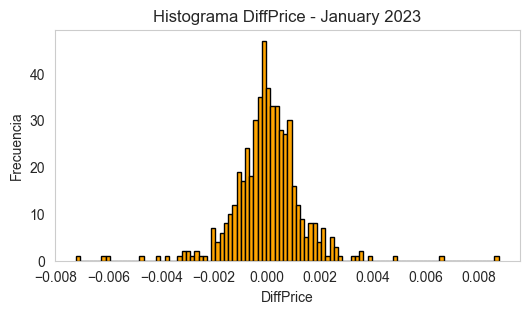

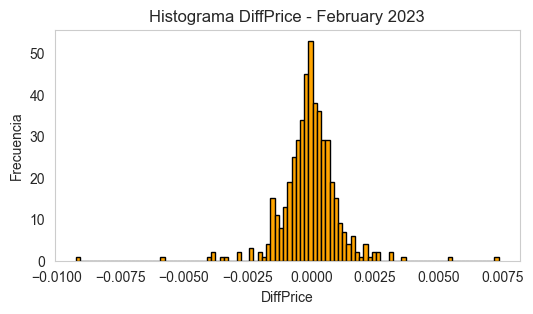

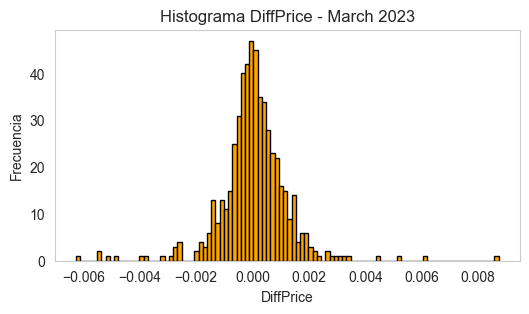

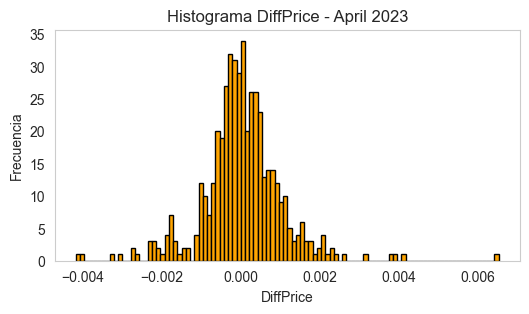

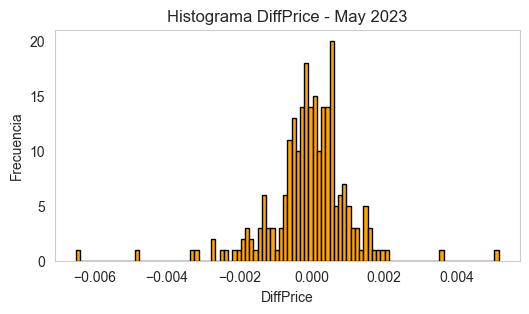

In [145]:
# 9. Histograma de DiffPrice por mes
for name, group in df_2023.groupby(pd.Grouper(freq='ME')):
    plt.figure(figsize=(6,3))
    plt.hist(group['DiffPrice'], bins=100, color='orange', edgecolor='black')
    plt.title(f'Histograma DiffPrice - {name.strftime("%B %Y")}')
    plt.xlabel('DiffPrice')
    plt.ylabel('Frecuencia')
    plt.grid()
    plt.show()

## Analisis de datos con Pandas

Para el siguiente [dataset](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29) realizar lo siguiente:


1. Leer los datos desde una página web.

2. Renombrar las columnas en formato PascalCase.

3. Utilizar los métodos `head()`, `tail()`, `describe()` e `info()` para obtener información sobre el `DataFrame`.

4. Contabilizar la cantidad de valores nulos (`null` o `NaN`) en el `DataFrame`.
   Si se encuentran valores nulos, ¿qué estrategia propondrías para reemplazarlos?

5. Identificar los valores únicos en la columna `target` que representan las etiquetas B y M (Benigno y Maligno, respectivamente).
   Utiliza el método `unique()` para mostrar estos valores.

6. Realizar un conteo de los casos etiquetados como B y M utilizando la librería `seaborn` y el método `countplot()`:

```python
import seaborn as sns
sns.countplot?
```

7. Agregar una nueva columna llamada `DiagnosisNumeric` donde se asigna el valor 0 a la etiqueta B (Benigno) y el valor 1 a la etiqueta M (Maligno).


8. Normalizar cada columna respecto a su media y desviación estándar utilizando la fórmula:  
   `(x - mean(x)) / std(x)`

9. Agrupar características similares y calcular su promedio.
   Para las siguientes características:

```python
['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', "SymmetryMean", "FractalDimensionMean"]
```

Usa expresiones regulares para identificar patrones comunes, como `radius1`, `radius2`,`radius3`, etc., y calcular los promedios. Por ejemplo:

```python
re.match(r'^[a-zA-Z_]+', "holamundo12341").group(0)
```

También puedes utilizar el método `startswith()` para buscar estos patrones en los nombres de las columnas.


10. Crear un gráfico donde se muestre el histograma de la columna `RadiusMean` separado por las etiquetas B y M, utilizando colores diferentes (naranja y azul, respectivamente) para cada diagnóstico.

11. Generar gráficos de violín para múltiples características.
   Para las columnas:

   - `RadiusMean`
   - `TextureMean`
   - `PerimeterMean`
   - `AreaMean`
   - `SmoothnessMean`
   - `CompactnessMean`
   - `ConcavityMean`
   - `ConcavePointsMean`
   - `Symmetry3`
   - `FractalDimension3`

   Realiza un gráfico múltiple tipo violín, como en el siguiente ejemplo:

```python
data = pd.melt(df.iloc[:, 0:10], id_vars="Diagnosis", var_name="features", value_name="value")
sns.violinplot(x="features", y="value", hue="Diagnosis", data=data, split=True, inner="quart")
plt.xticks(rotation=45)
```


12.  Determinar y eliminar los valores atípicos (`outliers`) en la columna `RadiusMean`.

Para identificarlos, construye un gráfico tipo `boxplot`:

```python
df.boxplot(column="RadiusMean", by='Diagnosis', sym='k.', figsize=(18,6))
```

Usa el rango intercuartílico (IQR) para definir los outliers. Los valores fuera del rango [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR] se consideran outliers. Ejemplo de cómo eliminar estos valores:

```python
Q1 = df['edad'].quantile(0.25)
Q3 = df['edad'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['edad'] < (Q1 - 1.5 * IQR)) | (df['edad'] > (Q3 + 1.5 * IQR)))]
```

Otra alternativa es utilizar el puntaje Z para detectar `outliers`:

```python 
df = df[(np.abs(stats.zscore(df['edad'])) < 3)]
```



13. Encontrar la matrix de correlación, emplear el metodo corr(), dentro de seaborn buscar el metodo heatmap() para realizar un grafico de la matrix de correlación.

14. ¿Que otro tipo de gráficos pueden ser realizados para entender mejor los datos?

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re
from ucimlrepo import fetch_ucirepo  # Repositorio donde se saca el dataset

# Configurar estilos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [147]:
# 1. Leer los datos desde la pagina web

# Descargamos el dataset desde UCI Machine Learning Repository
breast_cancer = fetch_ucirepo(id=17)

# Obtener features (X) y target (y)
X = breast_cancer.data.features.copy()
y = breast_cancer.data.targets.copy()

# Unir en un único DataFrame
df = pd.concat([X, y], axis=1)

print(f"Forma del DataFrame: {df.shape}")
print(f"\nPrimeras columnas originales:\n{df.columns.tolist()[:5]}")

Forma del DataFrame: (569, 31)

Primeras columnas originales:
['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1']


In [148]:
# 2. Renombramos ahora las columnas a PascalCase

# Tengammos en cuenta dataset usa formato: radius1, radius2, radius3 (Mean, SE, Worst)
# 1 = Mean, 2 = SE (Standard Error), 3 = Worst

rename_map = {
    "diagnosis": "Diagnosis",
    # Mean values (1)
    "radius1": "RadiusMean",
    "texture1": "TextureMean",
    "perimeter1": "PerimeterMean",
    "area1": "AreaMean",
    "smoothness1": "SmoothnessMean",
    "compactness1": "CompactnessMean",
    "concavity1": "ConcavityMean",
    "concave_points1": "ConcavePointsMean",
    "symmetry1": "SymmetryMean",
    "fractal_dimension1": "FractalDimensionMean",
    # SE values (2)
    "radius2": "RadiusSe",
    "texture2": "TextureSe",
    "perimeter2": "PerimeterSe",
    "area2": "AreaSe",
    "smoothness2": "SmoothnessSe",
    "compactness2": "CompactnessSe",
    "concavity2": "ConcavitySe",
    "concave_points2": "ConcavePointsSe",
    "symmetry2": "SymmetrySe",
    "fractal_dimension2": "FractalDimensionSe",
    # Worst values (3)
    "radius3": "RadiusWorst",
    "texture3": "TextureWorst",
    "perimeter3": "PerimeterWorst",
    "area3": "AreaWorst",
    "smoothness3": "SmoothnessWorst",
    "compactness3": "CompactnessWorst",
    "concavity3": "ConcavityWorst",
    "concave_points3": "ConcavePointsWorst",
    "symmetry3": "SymmetryWorst",
    "fractal_dimension3": "FractalDimensionWorst",
}

# Aplicamos el renombramiento
df = df.rename(columns=rename_map)

print("Columnas en PascalCase:")
print(df.columns.tolist())

Columnas en PascalCase:
['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', 'SymmetryMean', 'FractalDimensionMean', 'RadiusSe', 'TextureSe', 'PerimeterSe', 'AreaSe', 'SmoothnessSe', 'CompactnessSe', 'ConcavitySe', 'ConcavePointsSe', 'SymmetrySe', 'FractalDimensionSe', 'RadiusWorst', 'TextureWorst', 'PerimeterWorst', 'AreaWorst', 'SmoothnessWorst', 'CompactnessWorst', 'ConcavityWorst', 'ConcavePointsWorst', 'SymmetryWorst', 'FractalDimensionWorst', 'Diagnosis']


In [149]:
# 3. Exploración inicial del DataFrame

# Primeras filas del DataFrame
print("=" * 80)
print("PRIMERAS FILAS (head):")
print("=" * 80)
print(df.head())

PRIMERAS FILAS (head):
   RadiusMean  TextureMean  PerimeterMean  AreaMean  SmoothnessMean  \
0       17.99        10.38         122.80    1001.0         0.11840   
1       20.57        17.77         132.90    1326.0         0.08474   
2       19.69        21.25         130.00    1203.0         0.10960   
3       11.42        20.38          77.58     386.1         0.14250   
4       20.29        14.34         135.10    1297.0         0.10030   

   CompactnessMean  ConcavityMean  ConcavePointsMean  SymmetryMean  \
0          0.27760         0.3001            0.14710        0.2419   
1          0.07864         0.0869            0.07017        0.1812   
2          0.15990         0.1974            0.12790        0.2069   
3          0.28390         0.2414            0.10520        0.2597   
4          0.13280         0.1980            0.10430        0.1809   

   FractalDimensionMean  ...  TextureWorst  PerimeterWorst  AreaWorst  \
0               0.07871  ...         17.33          184.

In [150]:
# Últimas filas del DataFrame
print("\n" + "=" * 80)
print("ÚLTIMAS FILAS (tail):")
print("=" * 80)
print(df.tail())


ÚLTIMAS FILAS (tail):
     RadiusMean  TextureMean  PerimeterMean  AreaMean  SmoothnessMean  \
564       21.56        22.39         142.00    1479.0         0.11100   
565       20.13        28.25         131.20    1261.0         0.09780   
566       16.60        28.08         108.30     858.1         0.08455   
567       20.60        29.33         140.10    1265.0         0.11780   
568        7.76        24.54          47.92     181.0         0.05263   

     CompactnessMean  ConcavityMean  ConcavePointsMean  SymmetryMean  \
564          0.11590        0.24390            0.13890        0.1726   
565          0.10340        0.14400            0.09791        0.1752   
566          0.10230        0.09251            0.05302        0.1590   
567          0.27700        0.35140            0.15200        0.2397   
568          0.04362        0.00000            0.00000        0.1587   

     FractalDimensionMean  ...  TextureWorst  PerimeterWorst  AreaWorst  \
564               0.05623  ...

In [151]:
# Estadísticas descriptivas
print("\n" + "=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS (describe):")
print("=" * 80)
print(df.describe())


ESTADÍSTICAS DESCRIPTIVAS (describe):
       RadiusMean  TextureMean  PerimeterMean     AreaMean  SmoothnessMean  \
count  569.000000   569.000000     569.000000   569.000000      569.000000   
mean    14.127292    19.289649      91.969033   654.889104        0.096360   
std      3.524049     4.301036      24.298981   351.914129        0.014064   
min      6.981000     9.710000      43.790000   143.500000        0.052630   
25%     11.700000    16.170000      75.170000   420.300000        0.086370   
50%     13.370000    18.840000      86.240000   551.100000        0.095870   
75%     15.780000    21.800000     104.100000   782.700000        0.105300   
max     28.110000    39.280000     188.500000  2501.000000        0.163400   

       CompactnessMean  ConcavityMean  ConcavePointsMean  SymmetryMean  \
count       569.000000     569.000000         569.000000    569.000000   
mean          0.104341       0.088799           0.048919      0.181162   
std           0.052813       0.07972

In [152]:
# Información general del DataFrame
print("\n" + "=" * 80)
print("INFORMACIÓN GENERAL (info):")
print("=" * 80)
print(df.info())


INFORMACIÓN GENERAL (info):
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RadiusMean             569 non-null    float64
 1   TextureMean            569 non-null    float64
 2   PerimeterMean          569 non-null    float64
 3   AreaMean               569 non-null    float64
 4   SmoothnessMean         569 non-null    float64
 5   CompactnessMean        569 non-null    float64
 6   ConcavityMean          569 non-null    float64
 7   ConcavePointsMean      569 non-null    float64
 8   SymmetryMean           569 non-null    float64
 9   FractalDimensionMean   569 non-null    float64
 10  RadiusSe               569 non-null    float64
 11  TextureSe              569 non-null    float64
 12  PerimeterSe            569 non-null    float64
 13  AreaSe                 569 non-null    float64
 14  SmoothnessSe           569 non-null    f

In [153]:
# 4. Analisis de valores nulos o NaN

# Contabilizar valores nulos por columna
print("=" * 80)
print("VALORES NULOS POR COLUMNA:")
print("=" * 80)
null_counts = df.isnull().sum()
print(null_counts)

print("\n" + "=" * 80)
print("TOTAL DE VALORES NULOS EN EL DATAFRAME:")
print("=" * 80)
total_nulls = df.isnull().sum().sum()
print(f"Total de valores nulos: {total_nulls}")
print(f"Porcentaje de nulos: {(total_nulls / (df.shape[0] * df.shape[1]) * 100):.2f}%")

print("\n" + "=" * 80)
print("ESTRATEGIA PARA MANEJAR VALORES NULOS: ")
print("=" * 80)
if total_nulls == 0:
    print("✓ No hay valores nulos en el DataFrame. El dataset está completo.")
else:
    print("Estrategias propuestas en caso de encontrar nulos:")
    print("  1. ELIMINACIÓN: Si hay pocos nulos (<5%), eliminar las filas con nulos.")
    print("  2. IMPUTACIÓN CON MEDIANA: Robusta a outliers, ideal para datos skewad.")
    print("  3. IMPUTACIÓN CON MEDIA: Para distribuciones simétricas.")
    print("  4. FORWARD FILL / BACKWARD FILL: Para series de tiempo.")
    print("  5. INTERPOLACIÓN: Para valores faltantes entre datos consecutivos.")


VALORES NULOS POR COLUMNA:
RadiusMean               0
TextureMean              0
PerimeterMean            0
AreaMean                 0
SmoothnessMean           0
CompactnessMean          0
ConcavityMean            0
ConcavePointsMean        0
SymmetryMean             0
FractalDimensionMean     0
RadiusSe                 0
TextureSe                0
PerimeterSe              0
AreaSe                   0
SmoothnessSe             0
CompactnessSe            0
ConcavitySe              0
ConcavePointsSe          0
SymmetrySe               0
FractalDimensionSe       0
RadiusWorst              0
TextureWorst             0
PerimeterWorst           0
AreaWorst                0
SmoothnessWorst          0
CompactnessWorst         0
ConcavityWorst           0
ConcavePointsWorst       0
SymmetryWorst            0
FractalDimensionWorst    0
Diagnosis                0
dtype: int64

TOTAL DE VALORES NULOS EN EL DATAFRAME:
Total de valores nulos: 0
Porcentaje de nulos: 0.00%

ESTRATEGIA PARA MANEJAR VALO

In [154]:
# 5 Analisis de la variable Target (Diagnosis)

# Valores únicos en Diagnosis
print("=" * 80)
print("VALORES ÚNICOS EN LA COLUMNA 'Diagnosis':")
print("=" * 80)
unique_diagnoses = df['Diagnosis'].unique()
print(f"Valores únicos: {unique_diagnoses}")
print(f"\nSignificado:")
print(f"  B = Benigno (tumor no canceroso)")
print(f"  M = Maligno (tumor canceroso)")

# Conteo por categoría
print("\n" + "=" * 80)
print("DISTRIBUCIÓN DE DIAGNÓSTICOS:")
print("=" * 80)
diagnosis_counts = df['Diagnosis'].value_counts()
print(diagnosis_counts)
print(f"\nProporción:")
print(diagnosis_counts / len(df) * 100)

VALORES ÚNICOS EN LA COLUMNA 'Diagnosis':
Valores únicos: <StringArray>
['M', 'B']
Length: 2, dtype: str

Significado:
  B = Benigno (tumor no canceroso)
  M = Maligno (tumor canceroso)

DISTRIBUCIÓN DE DIAGNÓSTICOS:
Diagnosis
B    357
M    212
Name: count, dtype: int64

Proporción:
Diagnosis
B    62.741652
M    37.258348
Name: count, dtype: float64


C:\Users\Biohealthy\AppData\Local\Temp\ipykernel_3032\3932748876.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Diagnosis', palette=colores, order=['B', 'M'])


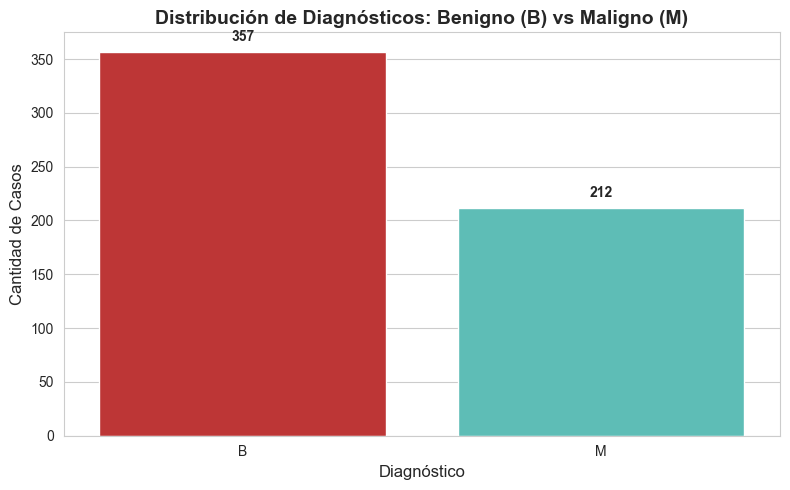

In [155]:
# 6 Vizualización de distribución de diagnósticos.

# Gráfico countplot sin warning de paleta
plt.figure(figsize=(8, 5))
# Definir lista de colores en el mismo orden que 'order'
colores = ["#D32020", "#4ECDC4"]  # B, M
sns.countplot(data=df, x='Diagnosis', palette=colores, order=['B', 'M'])
plt.title('Distribución de Diagnósticos: Benigno (B) vs Maligno (M)', fontsize=14, fontweight='bold')
plt.xlabel('Diagnóstico', fontsize=12)
plt.ylabel('Cantidad de Casos', fontsize=12)
plt.text(0, df[df['Diagnosis']=='B'].shape[0] + 10, f"{df[df['Diagnosis']=='B'].shape[0]}", ha='center', fontweight='bold')
plt.text(1, df[df['Diagnosis']=='M'].shape[0] + 10, f"{df[df['Diagnosis']=='M'].shape[0]}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [156]:
# 7. Codificación numérica del Target (Diagnosis)

# Crear columna DiagnosisNumeric
df['DiagnosisNumeric'] = df['Diagnosis'].map({'B': 0, 'M': 1})

print("=" * 80)
print("CODIFICACIÓN NUMÉRICA DEL TARGET:")
print("=" * 80)
print(f"\nMapeo:")
print(f"  B (Benigno) → 0")
print(f"  M (Maligno) → 1")

print("\nPrimeras filas con DiagnosisNumeric:")
print(df[['Diagnosis', 'DiagnosisNumeric']].head(10))

CODIFICACIÓN NUMÉRICA DEL TARGET:

Mapeo:
  B (Benigno) → 0
  M (Maligno) → 1

Primeras filas con DiagnosisNumeric:
  Diagnosis  DiagnosisNumeric
0         M                 1
1         M                 1
2         M                 1
3         M                 1
4         M                 1
5         M                 1
6         M                 1
7         M                 1
8         M                 1
9         M                 1


In [157]:
# 8. Normalización de las características numéricas

# Crear una copia para normalizar
df_normalized = df.copy()

# Identificar columnas numéricas (excluyendo Diagnosis y DiagnosisNumeric)
numeric_cols = df_normalized.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'DiagnosisNumeric']

# Normalizar: (x - media) / desviación estándar
for col in numeric_cols:
    media = df_normalized[col].mean()
    std = df_normalized[col].std()
    df_normalized[col] = (df_normalized[col] - media) / std

print("=" * 80)
print("NORMALIZACIÓN DE CARACTERÍSTICAS:")
print("=" * 80)
print(f"Fórmula aplicada: (x - media) / desviación estándar")
print(f"Número de columnas normalizadas: {len(numeric_cols)}")

print("\nPrimeras filas ANTES de normalización:")
print(df[['RadiusMean', 'TextureMean', 'PerimeterMean']].head())

print("\nPrimeras filas DESPUÉS de normalización:")
print(df_normalized[['RadiusMean', 'TextureMean', 'PerimeterMean']].head())

print("\nEstadísticas después de normalización (media ≈ 0, std ≈ 1):")
print(df_normalized[numeric_cols].describe())

NORMALIZACIÓN DE CARACTERÍSTICAS:
Fórmula aplicada: (x - media) / desviación estándar
Número de columnas normalizadas: 30

Primeras filas ANTES de normalización:
   RadiusMean  TextureMean  PerimeterMean
0       17.99        10.38         122.80
1       20.57        17.77         132.90
2       19.69        21.25         130.00
3       11.42        20.38          77.58
4       20.29        14.34         135.10

Primeras filas DESPUÉS de normalización:
   RadiusMean  TextureMean  PerimeterMean
0    1.096100    -2.071512       1.268817
1    1.828212    -0.353322       1.684473
2    1.578499     0.455786       1.565126
3   -0.768233     0.253509      -0.592166
4    1.748758    -1.150804       1.775011

Estadísticas después de normalización (media ≈ 0, std ≈ 1):
         RadiusMean   TextureMean  PerimeterMean      AreaMean  \
count  5.690000e+02  5.690000e+02   5.690000e+02  5.690000e+02   
mean  -1.311195e-16  6.243785e-17  -1.248757e-16 -2.185325e-16   
std    1.000000e+00  1.000000e+00

In [158]:
# 9. Agrupación y promedio de características por diagnóstico

# Características Mean a promediar
mean_features = ['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 
                 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 
                 'ConcavePointsMean', 'SymmetryMean', 'FractalDimensionMean']

print("=" * 80)
print("AGRUPACIÓN DE CARACTERÍSTICAS CON EXPRESIONES REGULARES:")
print("=" * 80)

# Ejemplo de uso de regex
example = "RadiusMean"
match = re.match(r'^([A-Za-z]+)(Mean|Se|Worst)$', example)
if match:
    print(f"\nEjemplo: '{example}'")
    print(f"  Base: {match.group(1)}")
    print(f"  Tipo: {match.group(2)}")

# Crear diccionario de familias de características
feature_groups = {}
for col in df.columns:
    if col not in ['Diagnosis', 'DiagnosisNumeric']:
        match = re.match(r'^([A-Za-z]+)(Mean|Se|Worst)$', col)
        if match:
            base = match.group(1)
            feature_groups.setdefault(base, []).append(col)

print("\n" + "=" * 80)
print("FAMILIAS DE CARACTERÍSTICAS IDENTIFICADAS:")
print("=" * 80)
for base, cols in sorted(feature_groups.items()):
    print(f"\n{base}:")
    for col in sorted(cols):
        print(f"  - {col}")

# Crear DataFrame con promedios por familia
print("\n" + "=" * 80)
print("PROMEDIOS POR FAMILIA DE CARACTERÍSTICAS:")
print("=" * 80)
df_grouped = pd.DataFrame()
for base, cols in feature_groups.items():
    df_grouped[f'{base}Avg'] = df[cols].mean(axis=1)

print("\nPrimeras filas de promedios por familia:")
print(df_grouped.head())

# Promedio general de características Mean
print("\n" + "=" * 80)
print("PROMEDIO GENERAL DE CARACTERÍSTICAS MEAN:")
print("=" * 80)
df['MeanFeaturesAvg'] = df[mean_features].mean(axis=1)
print(df[['Diagnosis'] + mean_features + ['MeanFeaturesAvg']].head())

AGRUPACIÓN DE CARACTERÍSTICAS CON EXPRESIONES REGULARES:

Ejemplo: 'RadiusMean'
  Base: Radius
  Tipo: Mean

FAMILIAS DE CARACTERÍSTICAS IDENTIFICADAS:

Area:
  - AreaMean
  - AreaSe
  - AreaWorst

Compactness:
  - CompactnessMean
  - CompactnessSe
  - CompactnessWorst

ConcavePoints:
  - ConcavePointsMean
  - ConcavePointsSe
  - ConcavePointsWorst

Concavity:
  - ConcavityMean
  - ConcavitySe
  - ConcavityWorst

FractalDimension:
  - FractalDimensionMean
  - FractalDimensionSe
  - FractalDimensionWorst

Perimeter:
  - PerimeterMean
  - PerimeterSe
  - PerimeterWorst

Radius:
  - RadiusMean
  - RadiusSe
  - RadiusWorst

Smoothness:
  - SmoothnessMean
  - SmoothnessSe
  - SmoothnessWorst

Symmetry:
  - SymmetryMean
  - SymmetrySe
  - SymmetryWorst

Texture:
  - TextureMean
  - TextureSe
  - TextureWorst

PROMEDIOS POR FAMILIA DE CARACTERÍSTICAS:

Primeras filas de promedios por familia:
   RadiusAvg  TextureAvg  PerimeterAvg      AreaAvg  SmoothnessAvg  \
0  14.821667    9.538433    105

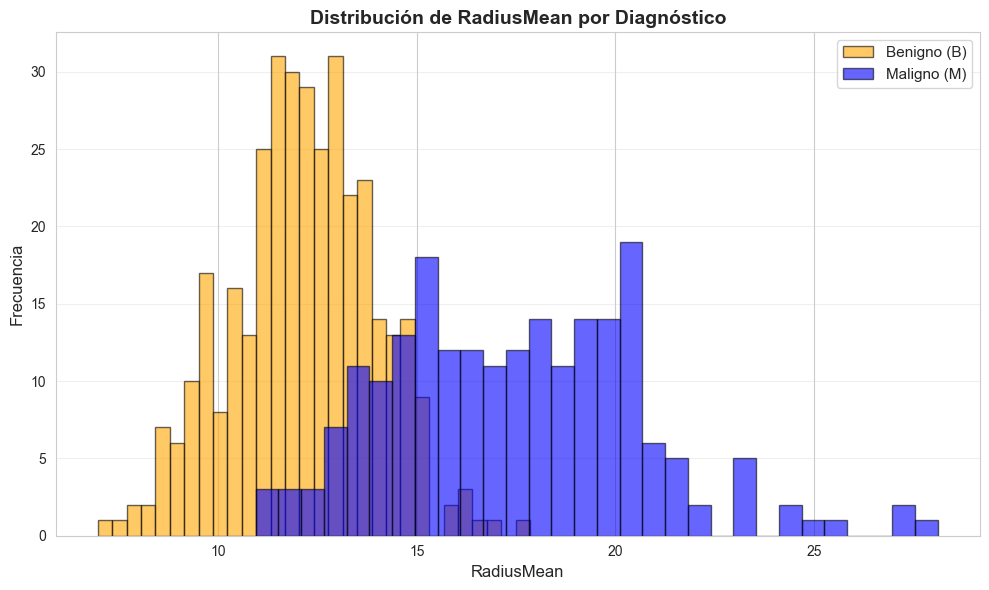

ESTADÍSTICAS DE RadiusMean POR DIAGNÓSTICO:

Benigno (B):
  Media: 12.1465
  Mediana: 12.2000
  Desv. Est.: 1.7805
  Mín: 6.9810
  Máx: 17.8500

Maligno (M):
  Media: 17.4628
  Mediana: 17.3250
  Desv. Est.: 3.2040
  Mín: 10.9500
  Máx: 28.1100


In [159]:
# 10. Histograma de RadiusMean separado por diagnóstico

# Histograma de RadiusMean por diagnóstico
plt.figure(figsize=(10, 6))

# Datos para cada grupo
radius_benigno = df[df['Diagnosis'] == 'B']['RadiusMean']
radius_maligno = df[df['Diagnosis'] == 'M']['RadiusMean']

# Crear histogramas
bins = 30
plt.hist(radius_benigno, bins=bins, alpha=0.6, label='Benigno (B)', color='orange', edgecolor='black')
plt.hist(radius_maligno, bins=bins, alpha=0.6, label='Maligno (M)', color='blue', edgecolor='black')

plt.title('Distribución de RadiusMean por Diagnóstico', fontsize=14, fontweight='bold')
plt.xlabel('RadiusMean', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Estadísticas por grupo
print("=" * 80)
print("ESTADÍSTICAS DE RadiusMean POR DIAGNÓSTICO:")
print("=" * 80)
print(f"\nBenigno (B):")
print(f"  Media: {radius_benigno.mean():.4f}")
print(f"  Mediana: {radius_benigno.median():.4f}")
print(f"  Desv. Est.: {radius_benigno.std():.4f}")
print(f"  Mín: {radius_benigno.min():.4f}")
print(f"  Máx: {radius_benigno.max():.4f}")

print(f"\nMaligno (M):")
print(f"  Media: {radius_maligno.mean():.4f}")
print(f"  Mediana: {radius_maligno.median():.4f}")
print(f"  Desv. Est.: {radius_maligno.std():.4f}")
print(f"  Mín: {radius_maligno.min():.4f}")
print(f"  Máx: {radius_maligno.max():.4f}")

VIOLIN PLOT CONJUNTO (DATOS NORMALIZADOS)


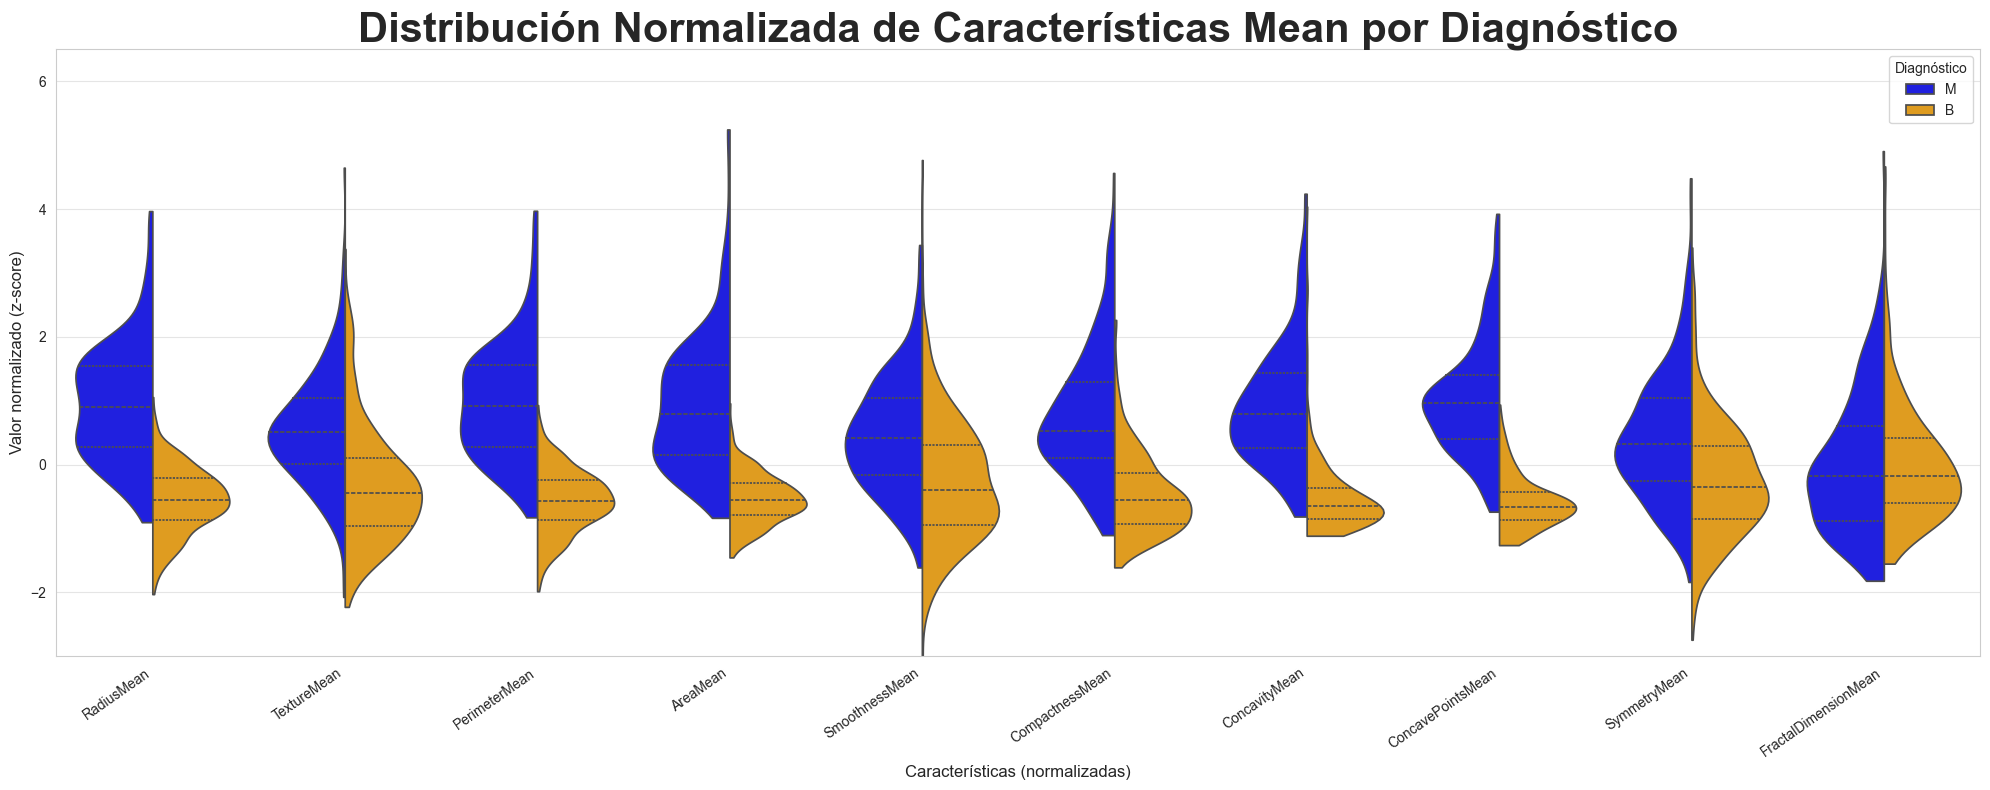

In [160]:
# 11. Gráfico de violín multivariado

# Gráfico de violín conjunto usando características normalizadas (z-score)
# Así todas las variables quedan en la misma escala y se pueden comparar en un solo gráfico.
features_to_plot = [
    'RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean',
    'SmoothnessMean', 'CompactnessMean', 'ConcavityMean',
    'ConcavePointsMean', 'SymmetryMean', 'FractalDimensionMean'
]

# Normalización para poner todos lo grádficos en un mismo plot
if 'df_normalized' not in globals():
    df_normalized = df.copy()
    numeric_cols = df_normalized.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col != 'DiagnosisNumeric']
    for col in numeric_cols:
        df_normalized[col] = (df_normalized[col] - df_normalized[col].mean()) / df_normalized[col].std()

# Formato largo para seaborn
df_melted_norm = pd.melt(df_normalized[features_to_plot + ['Diagnosis']], id_vars='Diagnosis', var_name='Feature', value_name='Value')

print("=" * 80)
print("VIOLIN PLOT CONJUNTO (DATOS NORMALIZADOS)")
print("=" * 80)

plt.figure(figsize=(20, 8))
sns.violinplot(
    data=df_melted_norm, x='Feature', y='Value', hue='Diagnosis', split=True, inner='quart', cut=0, density_norm='width', palette={'B': 'orange', 'M': 'blue'})

plt.title('Distribución Normalizada de Características Mean por Diagnóstico', fontsize=30, fontweight='bold')
plt.xlabel('Características (normalizadas)', fontsize=12)
plt.ylabel('Valor normalizado (z-score)', fontsize=12)
plt.xticks(rotation=35, ha='right')
plt.ylim(-3, 6.5)
plt.legend(title='Diagnóstico', fontsize=10)
plt.grid(axis='y', alpha = 0.5)
plt.tight_layout()
plt.show()

DETECCIÓN DE OUTLIERS EN RadiusMean:


<Figure size 1400x600 with 0 Axes>

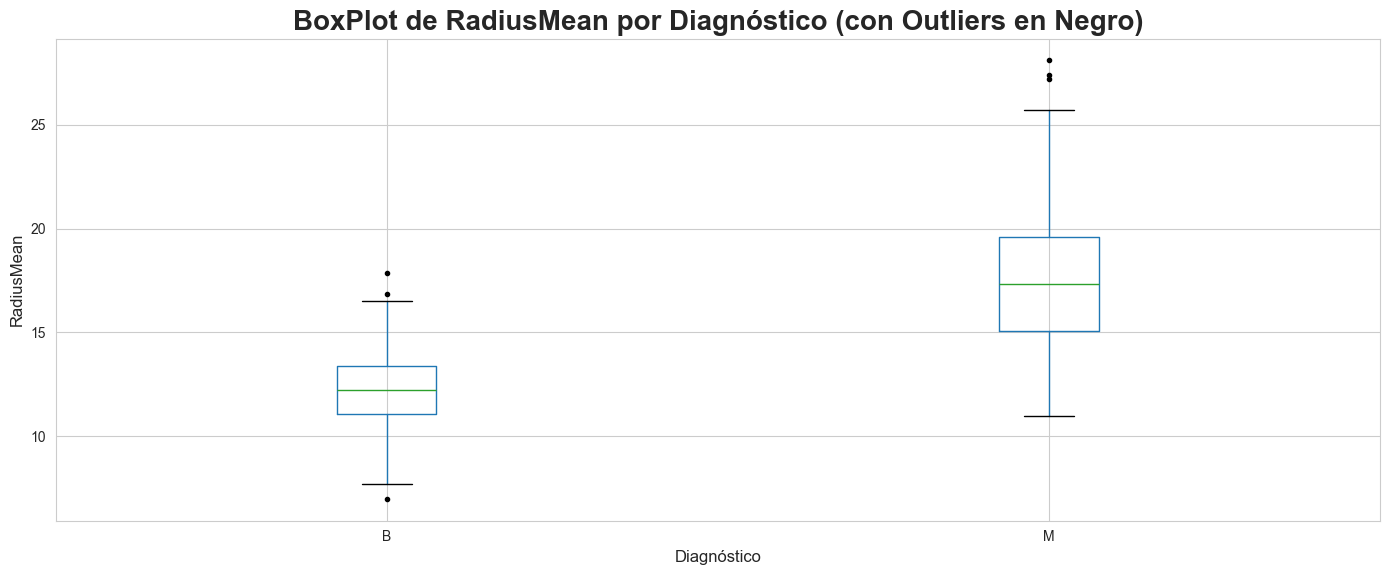


--------------------------------------------------------------------------------
MÉTODO 1: RANGO INTERCUARTÍLICO (IQR)
--------------------------------------------------------------------------------
Q1 (25th percentile): 11.7000
Q3 (75th percentile): 15.7800
IQR (Q3 - Q1): 4.0800

Límites de outliers:
  Inferior: Q1 - 1.5*IQR = 5.5800
  Superior: Q3 + 1.5*IQR = 21.9000

Número de outliers (IQR): 14
Porcentaje: 2.46%

Primeros outliers identificados por IQR:
     RadiusMean Diagnosis
82        25.22         M
108       22.27         M
122       24.25         M
164       23.27         M
180       27.22         M


In [161]:
# 12. detección y eliminación de outliers en AreaMean usando IQR

# Visualizar outliers con boxplot antes de eliminar
print("=" * 80)
print("DETECCIÓN DE OUTLIERS EN RadiusMean:")
print("=" * 80)

plt.figure(figsize=(14, 6))
df.boxplot(column='RadiusMean', by='Diagnosis', sym='k.', figsize=(14, 6))
plt.title('BoxPlot de RadiusMean por Diagnóstico (con Outliers en Negro)', fontsize=20, fontweight='bold')
plt.suptitle('')  # Remover el título automático
plt.xlabel('Diagnóstico', fontsize=12)
plt.ylabel('RadiusMean', fontsize=12)
plt.tight_layout()
plt.show()

# MÉTODO 1: RANGO INTERCUARTÍLICO (IQR)
print("\n" + "-" * 80)
print("MÉTODO 1: RANGO INTERCUARTÍLICO (IQR)")
print("-" * 80)

Q1 = df['RadiusMean'].quantile(0.25)
Q3 = df['RadiusMean'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): {Q1:.4f}")
print(f"Q3 (75th percentile): {Q3:.4f}")
print(f"IQR (Q3 - Q1): {IQR:.4f}")
print(f"\nLímites de outliers:")
print(f"  Inferior: Q1 - 1.5*IQR = {lower_bound:.4f}")
print(f"  Superior: Q3 + 1.5*IQR = {upper_bound:.4f}")

# Identificar outliers
outliers_iqr = df[(df['RadiusMean'] < lower_bound) | (df['RadiusMean'] > upper_bound)]
print(f"\nNúmero de outliers (IQR): {len(outliers_iqr)}")
print(f"Porcentaje: {len(outliers_iqr)/len(df)*100:.2f}%")

if len(outliers_iqr) > 0:
    print("\nPrimeros outliers identificados por IQR:")
    print(outliers_iqr[['RadiusMean', 'Diagnosis']].head())

In [162]:
# MÉTODO 2: PUNTAJE Z (Z-SCORE)
print("\n" + "-" * 80)
print("MÉTODO 2: PUNTAJE Z (Z-SCORE)")
print("-" * 80)
print("Determinación: valores con |Z-score| > 3 se consideran outliers")

z_scores = np.abs(stats.zscore(df['RadiusMean']))
outliers_zscore = df[z_scores > 3]

print(f"Número de outliers (Z-score > 3): {len(outliers_zscore)}")
print(f"Porcentaje: {len(outliers_zscore)/len(df)*100:.2f}%")

if len(outliers_zscore) > 0:
    print("\nPrimeros outliers identificados por Z-score:")
    print(outliers_zscore[['RadiusMean', 'Diagnosis']].head())

# ELIMINAR OUTLIERS
print("\n" + "=" * 80)
print("ELIMINACIÓN DE OUTLIERS:")
print("=" * 80)
print(f"DataFrame original: {df.shape[0]} filas")

# Crear DataFrame sin outliers (método IQR)
df_sin_outliers_iqr = df[~((df['RadiusMean'] < lower_bound) | (df['RadiusMean'] > upper_bound))].copy()
print(f"DataFrame sin outliers (IQR): {df_sin_outliers_iqr.shape[0]} filas")
print(f"Filas eliminadas: {df.shape[0] - df_sin_outliers_iqr.shape[0]}")

# Crear DataFrame sin outliers (método Z-score)
df_sin_outliers_zscore = df[z_scores <= 3].copy()
print(f"\nDataFrame sin outliers (Z-score): {df_sin_outliers_zscore.shape[0]} filas")
print(f"Filas eliminadas: {df.shape[0] - df_sin_outliers_zscore.shape[0]}")

print("\n" + "=" * 80)
print("ESTADÍSTICAS ANTES Y DESPUÉS:")
print("=" * 80)
print(f"\nANTES (con outliers):")
print(f"  Media: {df['RadiusMean'].mean():.4f}")
print(f"  Mediana: {df['RadiusMean'].median():.4f}")
print(f"  Desv. Est.: {df['RadiusMean'].std():.4f}")

print(f"\nDESPUÉS (método IQR):")
print(f"  Media: {df_sin_outliers_iqr['RadiusMean'].mean():.4f}")
print(f"  Mediana: {df_sin_outliers_iqr['RadiusMean'].median():.4f}")
print(f"  Desv. Est.: {df_sin_outliers_iqr['RadiusMean'].std():.4f}")

print(f"\nDESPUÉS (método Z-score):")
print(f"  Media: {df_sin_outliers_zscore['RadiusMean'].mean():.4f}")
print(f"  Mediana: {df_sin_outliers_zscore['RadiusMean'].median():.4f}")
print(f"  Desv. Est.: {df_sin_outliers_zscore['RadiusMean'].std():.4f}")


--------------------------------------------------------------------------------
MÉTODO 2: PUNTAJE Z (Z-SCORE)
--------------------------------------------------------------------------------
Determinación: valores con |Z-score| > 3 se consideran outliers
Número de outliers (Z-score > 3): 5
Porcentaje: 0.88%

Primeros outliers identificados por Z-score:
     RadiusMean Diagnosis
82        25.22         M
180       27.22         M
212       28.11         M
352       25.73         M
461       27.42         M

ELIMINACIÓN DE OUTLIERS:
DataFrame original: 569 filas
DataFrame sin outliers (IQR): 555 filas
Filas eliminadas: 14

DataFrame sin outliers (Z-score): 564 filas
Filas eliminadas: 5

ESTADÍSTICAS ANTES Y DESPUÉS:

ANTES (con outliers):
  Media: 14.1273
  Mediana: 13.3700
  Desv. Est.: 3.5240

DESPUÉS (método IQR):
  Media: 13.8652
  Mediana: 13.2400
  Desv. Est.: 3.1379

DESPUÉS (método Z-score):
  Media: 14.0155
  Mediana: 13.2900
  Desv. Est.: 3.3307


MATRIZ DE CORRELACIÓN:
Forma de la matriz: (32, 32)

Primeras filas y columnas:
                RadiusMean  TextureMean  PerimeterMean  AreaMean  \
RadiusMean        1.000000     0.323782       0.997855  0.987357   
TextureMean       0.323782     1.000000       0.329533  0.321086   
PerimeterMean     0.997855     0.329533       1.000000  0.986507   
AreaMean          0.987357     0.321086       0.986507  1.000000   
SmoothnessMean    0.170581    -0.023389       0.207278  0.177028   

                SmoothnessMean  
RadiusMean            0.170581  
TextureMean          -0.023389  
PerimeterMean         0.207278  
AreaMean              0.177028  
SmoothnessMean        1.000000  


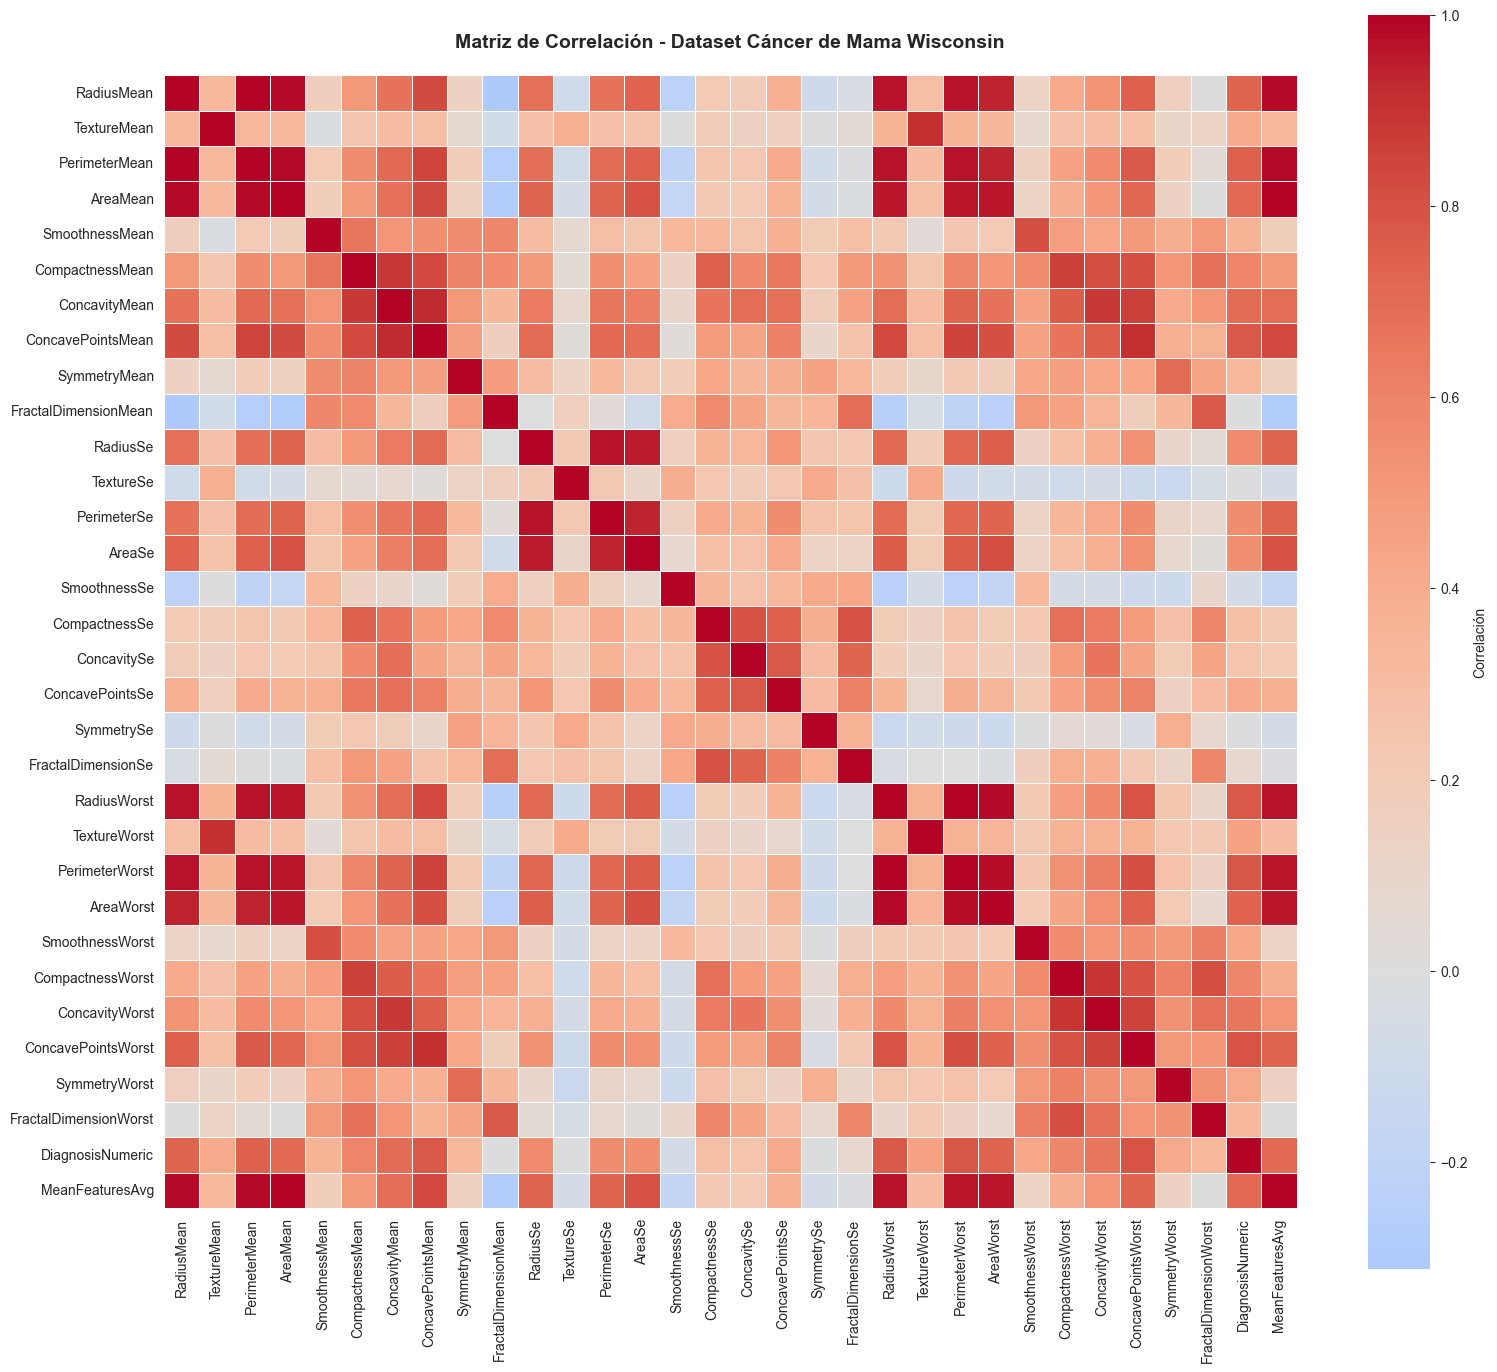


HEATMAP DE CORRELACIÓN - CARACTERÍSTICAS MEAN:


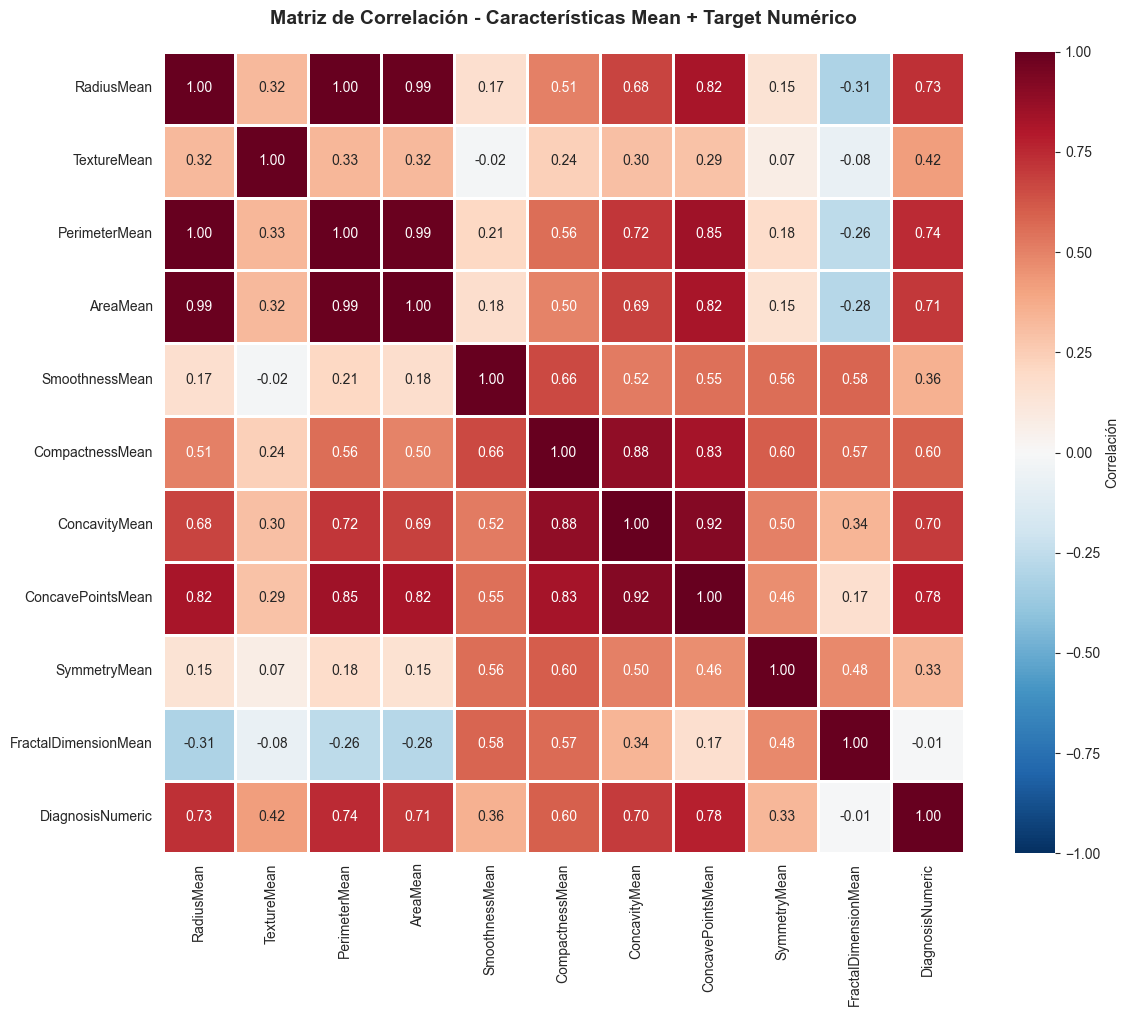


Correlaciones con DiagnosisNumeric (ordenadas por valor absoluto):
DiagnosisNumeric        1.000000
ConcavePointsMean       0.776614
PerimeterMean           0.742636
RadiusMean              0.730029
AreaMean                0.708984
ConcavityMean           0.696360
CompactnessMean         0.596534
TextureMean             0.415185
SmoothnessMean          0.358560
SymmetryMean            0.330499
FractalDimensionMean   -0.012838
Name: DiagnosisNumeric, dtype: float64


In [163]:
# 13. Matriz de correlación y heatmap

# Calcular matriz de correlación (solo columnas numéricas, excluyendo target categórico)
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

print("=" * 80)
print("MATRIZ DE CORRELACIÓN:")
print("=" * 80)
print(f"Forma de la matriz: {correlation_matrix.shape}")
print(f"\nPrimeras filas y columnas:")
print(correlation_matrix.iloc[:5, :5])

# Crear heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(
    correlation_matrix,
    annot=False,  # Demasiadas anotaciones, desactivar para claridad
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlación'}
)
plt.title('Matriz de Correlación - Dataset Cáncer de Mama Wisconsin', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Heatmap más pequeño con solo características Mean
print("\n" + "=" * 80)
print("HEATMAP DE CORRELACIÓN - CARACTERÍSTICAS MEAN:")
print("=" * 80)

mean_cols = ['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 
             'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 
             'ConcavePointsMean', 'SymmetryMean', 'FractalDimensionMean', 'DiagnosisNumeric']

if all(col in df.columns for col in mean_cols):
    correlation_mean = df[mean_cols].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        correlation_mean,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        square=True,
        linewidths=1,
        cbar_kws={'label': 'Correlación'},
        vmin=-1, vmax=1
    )
    plt.title('Matriz de Correlación - Características Mean + Target Numérico', 
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Encontrar correlaciones más significativas con el target
    print("\nCorrelaciones con DiagnosisNumeric (ordenadas por valor absoluto):")
    target_corr = correlation_mean['DiagnosisNumeric'].sort_values(ascending=False)
    print(target_corr)

GRÁFICOS ADICIONALES PARA ANÁLISIS EXPLORATORIO:

1. Generando PAIRPLOT (matriz de dispersión)...


<Figure size 1000x1000 with 0 Axes>

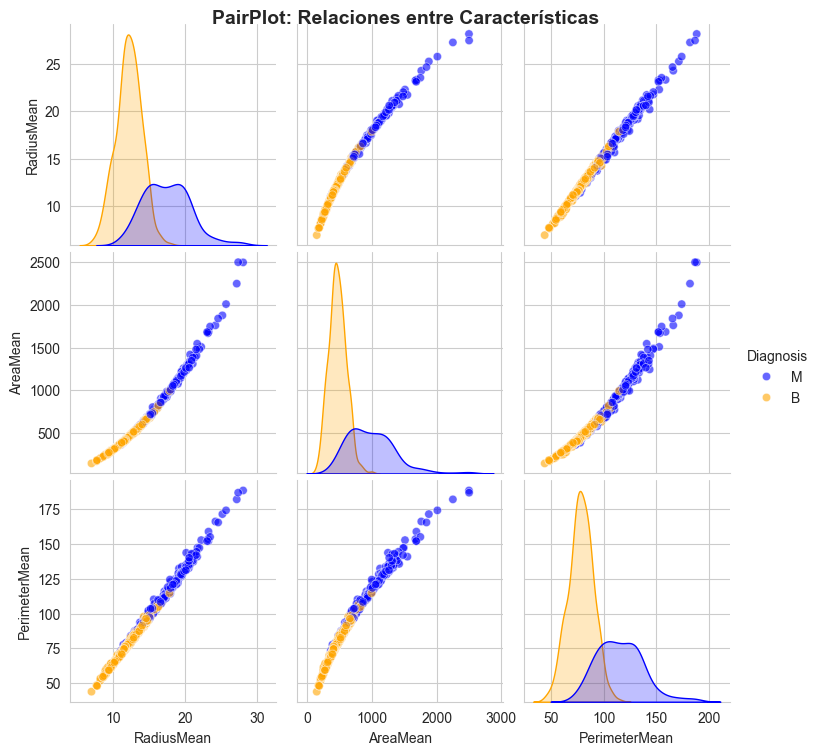

In [164]:
# 14. Algunos gráficos adicionales para explorar relaciones entre variables

# Generamos gráficos adicionales como pairplot, scatterplot, boxplot y barplot para obtener insights más profundos.

print("=" * 80)
print("GRÁFICOS ADICIONALES PARA ANÁLISIS EXPLORATORIO:")
print("=" * 80)

# 1. PAIRPLOT - Relaciones entre múltiples características
print("\n1. Generando PAIRPLOT (matriz de dispersión)...")
pairplot_features = ['RadiusMean', 'AreaMean', 'PerimeterMean', 'Diagnosis']
pairplot_df = df[pairplot_features].copy()

plt.figure(figsize=(10, 10))
sns.pairplot(pairplot_df, hue='Diagnosis', palette={'B': 'orange', 'M': 'blue'}, 
             diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('PairPlot: Relaciones entre Características', fontsize=14, fontweight='bold', y=1.00)
plt.show()


2. Generando SCATTERPLOT (dispersión)...


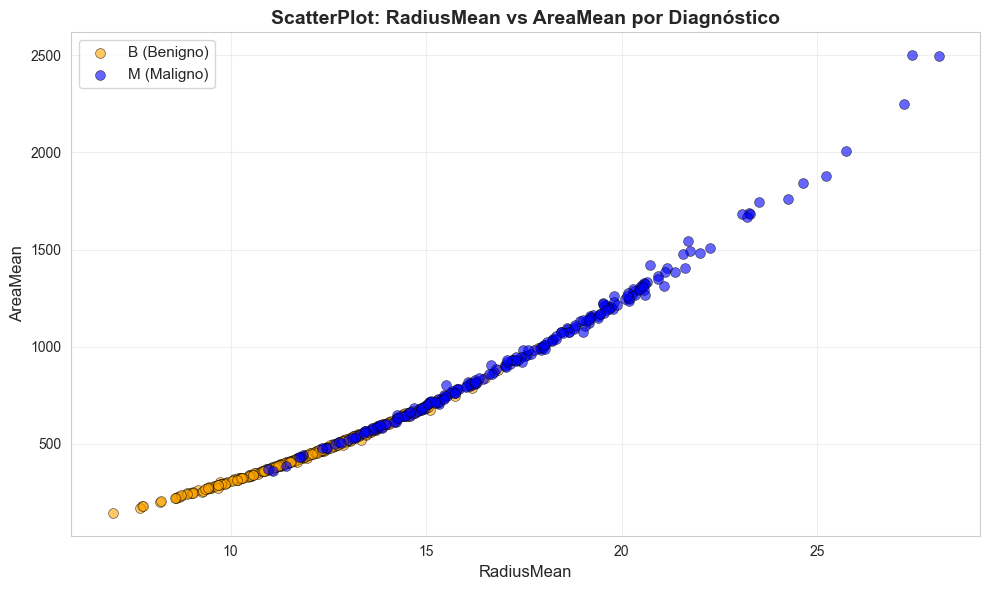

In [165]:
# 2. SCATTERPLOT - RadiousMean vs AreaMean coloreado por diagnóstico
print("\n2. Generando SCATTERPLOT (dispersión)...")
plt.figure(figsize=(10, 6))
for diagnosis, color in [('B', 'orange'), ('M', 'blue')]:
    mask = df['Diagnosis'] == diagnosis
    plt.scatter(df[mask]['RadiusMean'], df[mask]['AreaMean'], 
               label=f'{diagnosis} ({'Benigno' if diagnosis == 'B' else 'Maligno'})',
               alpha=0.6, s=50, color=color, edgecolors='black', linewidth=0.5)

plt.xlabel('RadiusMean', fontsize=12)
plt.ylabel('AreaMean', fontsize=12)
plt.title('ScatterPlot: RadiusMean vs AreaMean por Diagnóstico', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


3. Generando BOXPLOT de características múltiples...


C:\Users\Biohealthy\AppData\Local\Temp\ipykernel_3032\2530299136.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Diagnosis', y=feature, ax=axes[idx],
C:\Users\Biohealthy\AppData\Local\Temp\ipykernel_3032\2530299136.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Diagnosis', y=feature, ax=axes[idx],
C:\Users\Biohealthy\AppData\Local\Temp\ipykernel_3032\2530299136.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Diagnosis', y=feature, ax=axes[idx],
C:\Users\Biohealthy\AppData\Local\Temp\ipykern

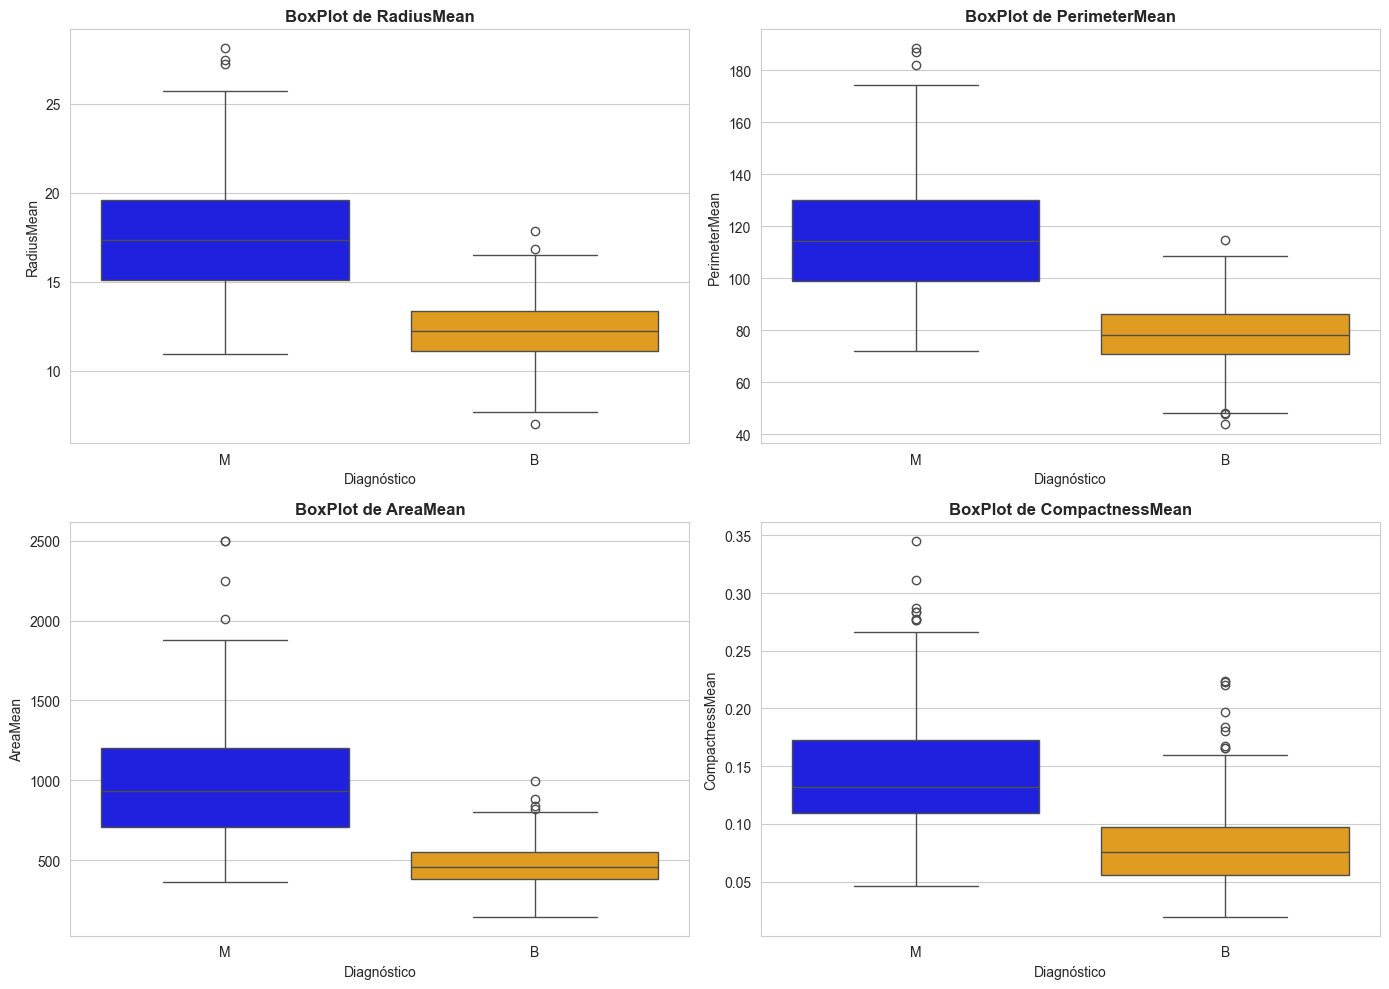

In [166]:
# 3. BOXPLOT - Múltiples características
print("\n3. Generando BOXPLOT de características múltiples...")
boxplot_features = ['RadiusMean', 'PerimeterMean', 'AreaMean', 'CompactnessMean']
df_boxplot = df[boxplot_features + ['Diagnosis']].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(boxplot_features):
    sns.boxplot(data=df, x='Diagnosis', y=feature, ax=axes[idx], 
               palette={'B': 'orange', 'M': 'blue'})
    axes[idx].set_title(f'BoxPlot de {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Diagnóstico', fontsize=10)
    axes[idx].set_ylabel(feature, fontsize=10)

plt.tight_layout()
plt.show()


4. Generando BARPLOT de promedios por diagnóstico...


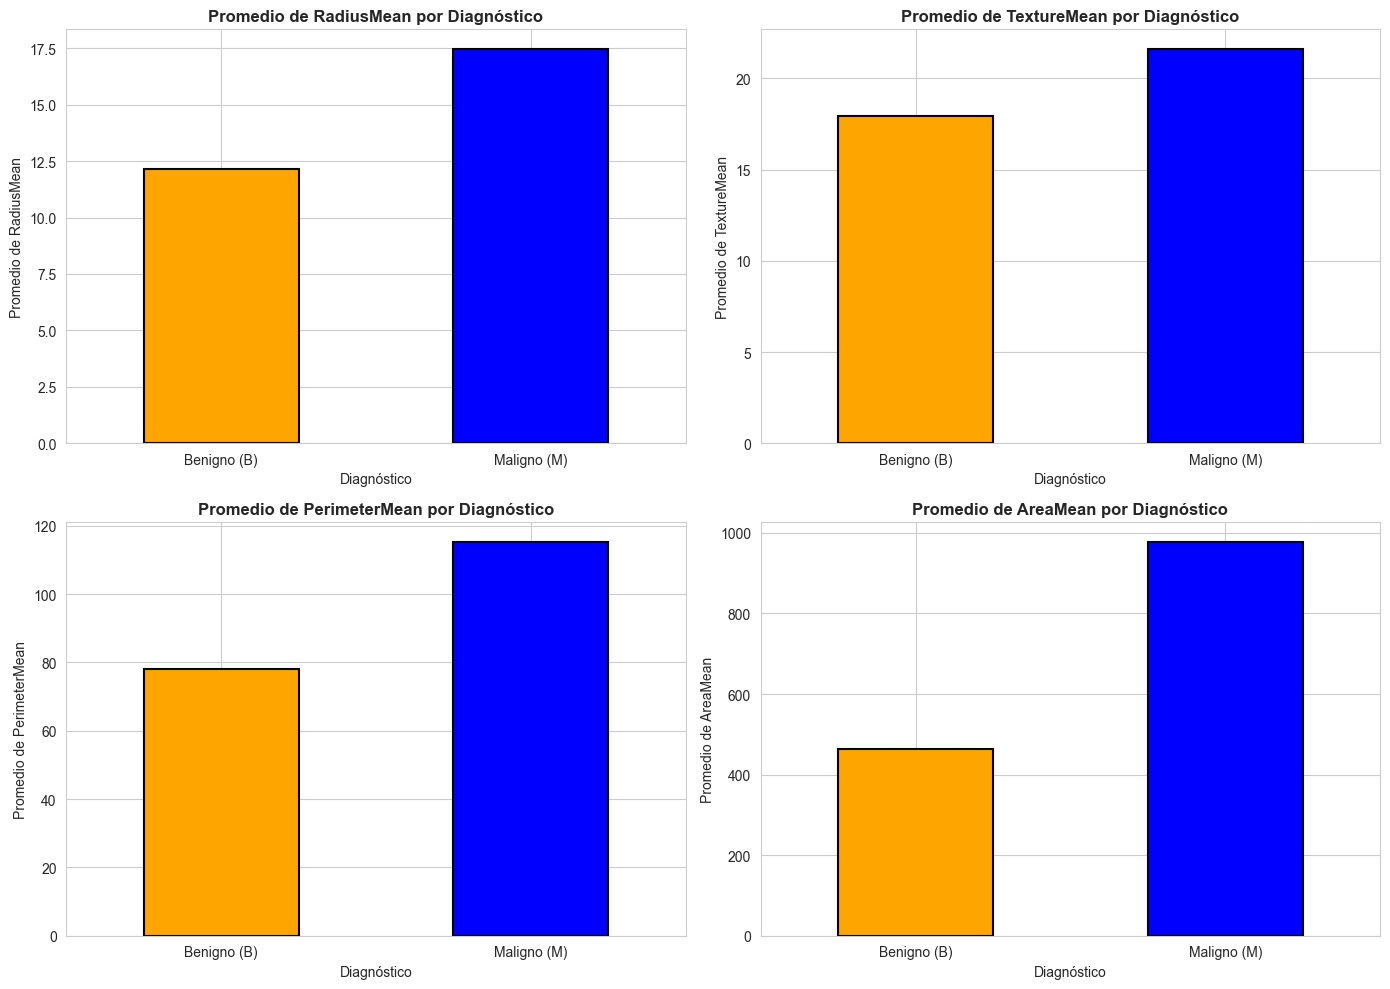

In [167]:
# 4. BARPLOT - Promedios de características por diagnóstico
print("\n4. Generando BARPLOT de promedios por diagnóstico...")
barplot_features = ['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean']
df_grouped = df.groupby('Diagnosis')[barplot_features].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(barplot_features):
    df_grouped[feature].plot(kind='bar', ax=axes[idx], 
                            color=['orange', 'blue'], edgecolor='black', linewidth=1.5)
    axes[idx].set_title(f'Promedio de {feature} por Diagnóstico', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Diagnóstico', fontsize=10)
    axes[idx].set_ylabel(f'Promedio de {feature}', fontsize=10)
    axes[idx].set_xticklabels(['Benigno (B)', 'Maligno (M)'], rotation=0)

plt.tight_layout()
plt.show()

## **Descripción de los graficos adicionales:**

**PairPlot:**

Nos revela que características como AreaMean, RadiusMean y PerimeterMean tienen una separación casi lineal entre las etiquetas B (benigno) y M (maligno). Tambien se observa que los tumores malignos tienden a tener valores más altos en estas variables, permitiendo distinguir visualmente ambos grupos.

**ScatterPlot:**

La dispersión entre RadiusMean y AreaMean muestra dos agrupaciones claras: los casos benignos se concentran en valores bajos de ambas variables, mientras que los malignos se agrupan en valores más altos. Esto indica que estas dos características juntas son muy útiles para diferenciar los diagnósticos separados.

**BoxPlot:**

Esto permite comparar la distribución y presencia de outliers de cada característica entre benignos y malignos. Donde se observa que los valores medianos y la dispersión de variables como RadiusMean y AreaMean son mayores en los casos malignos, y que hay más outliers en el grupo maligno.

**BarPlot:**

Aqui nos muestra que el promedio de cada característica (RadiusMean, TextureMean, PerimeterMean, AreaMean) es significativamente mayor en los tumores malignos que en los benignos. Esto refuerza la idea de que los tumores malignos suelen ser más grandes y con mayor textura/perímetro.